In [352]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [353]:
df = pd.read_csv('/content/demand_forecasting.csv')

In [354]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [356]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


In [357]:
df.duplicated().sum()

np.int64(0)

In [358]:
df.shape

(76000, 16)

In [359]:
df.describe(include='all')

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
count,76000,76000,76000,76000,76000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000,76000.000000,76000.000000,76000,76000.000000,76000.000000
unique,760,5,20,5,4,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,4,NaN,NaN
top,2024-01-30,S001,P0001,Groceries,North,NaN,NaN,NaN,NaN,NaN,Cloudy,NaN,NaN,Winter,NaN,NaN
freq,100,15200,3800,30400,30400,NaN,NaN,NaN,NaN,NaN,24360,NaN,NaN,21000,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,301.062842,88.827316,89.090645,67.726028,9.087039,NaN,0.328947,69.454029,NaN,0.200000,104.317158
std,NaN,NaN,NaN,NaN,NaN,226.510161,43.994525,162.404627,39.377899,7.475781,NaN,0.469834,40.943818,NaN,0.400003,46.964801
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,4.740000,0.000000,NaN,0.000000,4.290000,NaN,0.000000,4.000000
25%,NaN,NaN,NaN,NaN,NaN,136.000000,58.000000,0.000000,31.997500,5.000000,NaN,0.000000,32.620000,NaN,0.000000,71.000000
50%,NaN,NaN,NaN,NaN,NaN,227.000000,84.000000,0.000000,64.500000,10.000000,NaN,0.000000,65.700000,NaN,0.000000,100.000000
75%,NaN,NaN,NaN,NaN,NaN,408.000000,114.000000,121.000000,95.830000,10.000000,NaN,1.000000,97.932500,NaN,0.000000,133.000000


In [360]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [361]:
print(df["Store ID"].nunique())
print(df["Product ID"].nunique())

5
20


In [362]:
print(df["Store ID"].value_counts().head())
print(df["Product ID"].value_counts().head())

Store ID
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64
Product ID
P0001    3800
P0002    3800
P0003    3800
P0004    3800
P0005    3800
Name: count, dtype: int64


In [363]:
df[["Units Sold", "Demand"]].corr()


,Units Sold,Demand
Units Sold,1.000000,0.833421
Demand,0.833421,1.000000


In [364]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [365]:
df.head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1
5,2022-01-01,S001,P0006,Toys,North,209,60,0,35.53,0,Snowy,0,40.01,Winter,0,55,2022,1,1
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94,2022,1,1
7,2022-01-01,S001,P0008,Electronics,North,244,42,0,37.79,5,Snowy,0,44.85,Winter,0,61,2022,1,1
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129,2022,1,1
9,2022-01-01,S001,P0010,Furniture,North,192,70,300,113.35,10,Snowy,0,129.98,Winter,0,69,2022,1,1


In [366]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


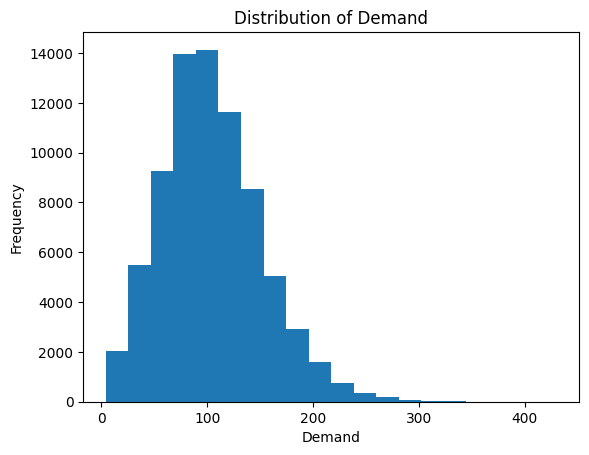

In [367]:
plt.hist(df['Demand'], bins=20)
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.title('Distribution of Demand')
plt.show()

<!-- Now create a Daily Demand Graph -->

In [368]:
# now lets create a daily demand graph

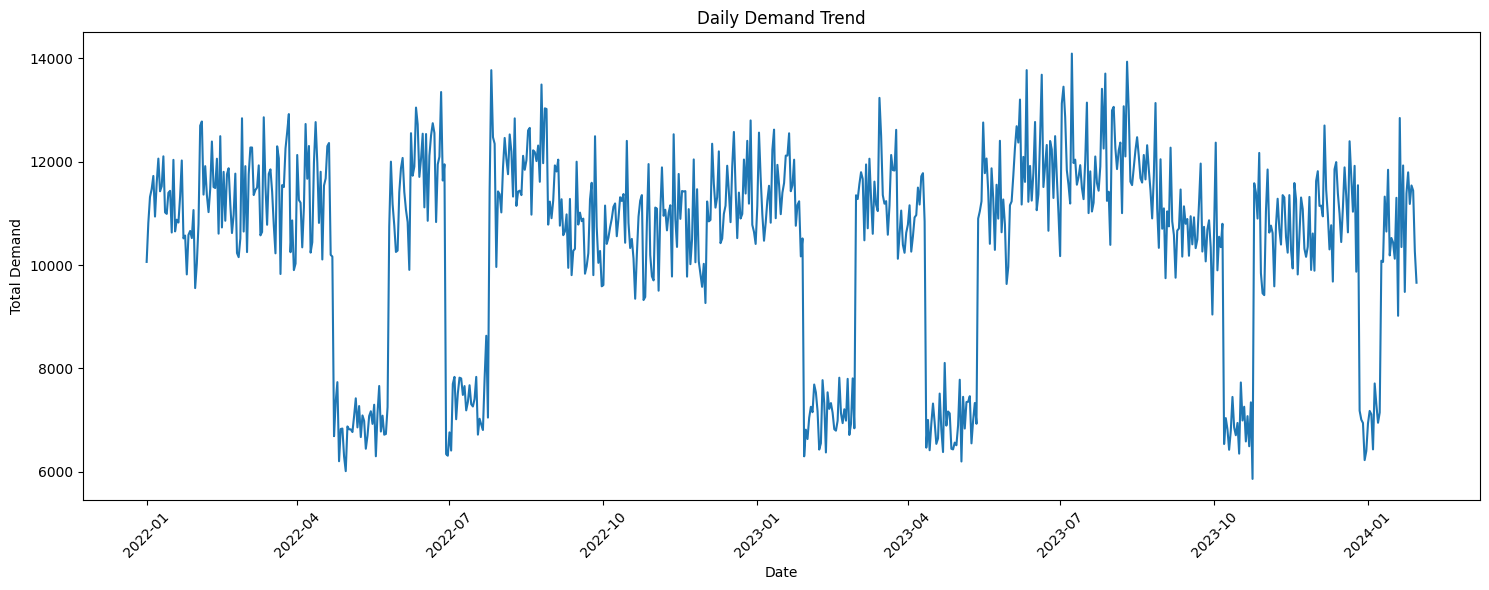

In [369]:
daily_demand = df.groupby("Date")["Demand"].sum()

plt.figure(figsize=(15,6))
plt.plot(daily_demand.index, daily_demand.values)
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [370]:
# Now lets create a monthly trend graph

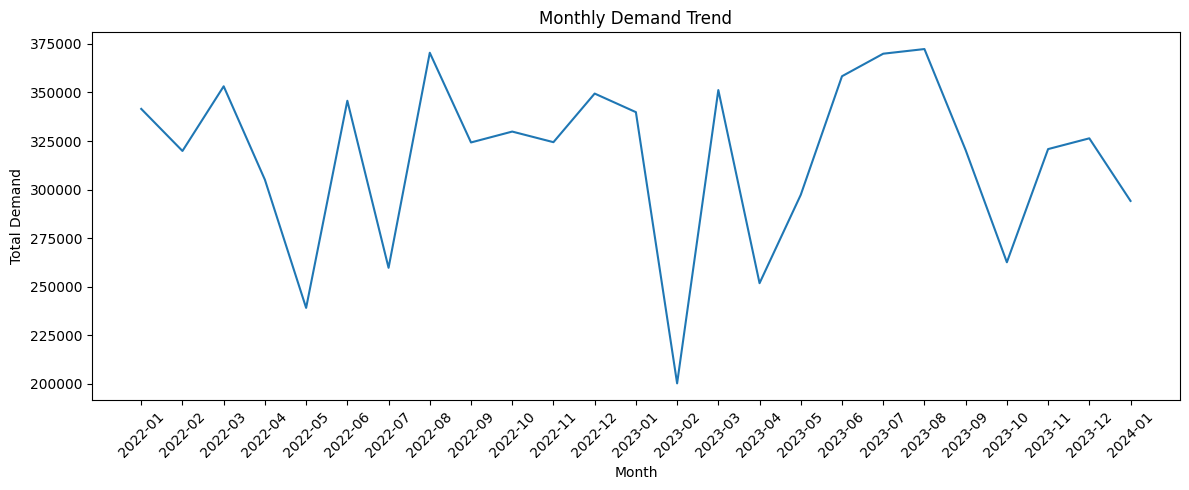

In [371]:
monthly_demand = df.groupby(df["Date"].dt.to_period("M"))["Demand"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_demand.index.astype(str), monthly_demand.values)
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [372]:
# Now category wise Graph

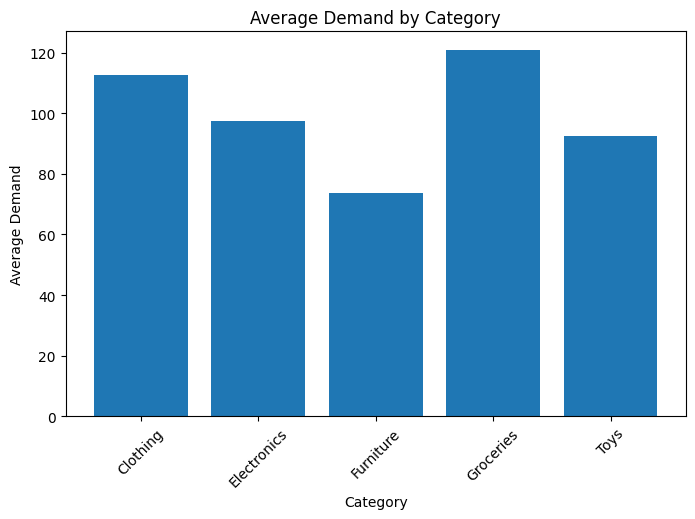

In [373]:
category = df.groupby("Category")["Demand"].mean()

plt.figure(figsize=(8,5))
plt.bar(category.index, category.values)
plt.title("Average Demand by Category")
plt.xlabel("Category")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

In [374]:
# Region Wise Graph

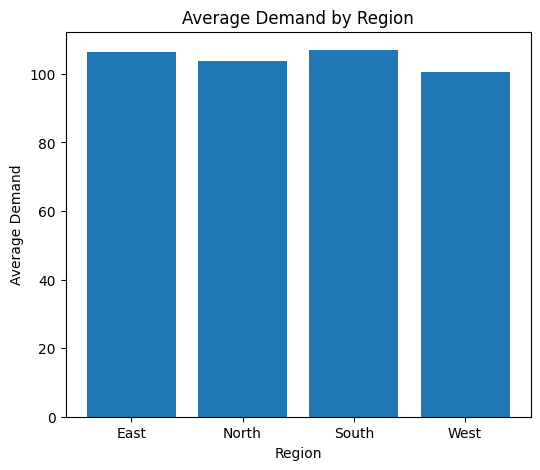

In [375]:
region = df.groupby("Region")["Demand"].mean()

plt.figure(figsize=(6,5))
plt.bar(region.index, region.values)
plt.title("Average Demand by Region")
plt.xlabel("Region")
plt.ylabel("Average Demand")
plt.show()

In [376]:
# Seasonality vs Demand

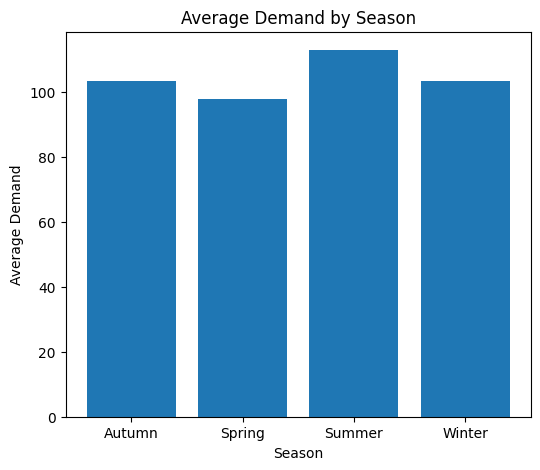

In [377]:
season = df.groupby("Seasonality")["Demand"].mean()

plt.figure(figsize=(6,5))
plt.bar(season.index, season.values)
plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Demand")
plt.show()

In [378]:
# Weather Condition vs Demand

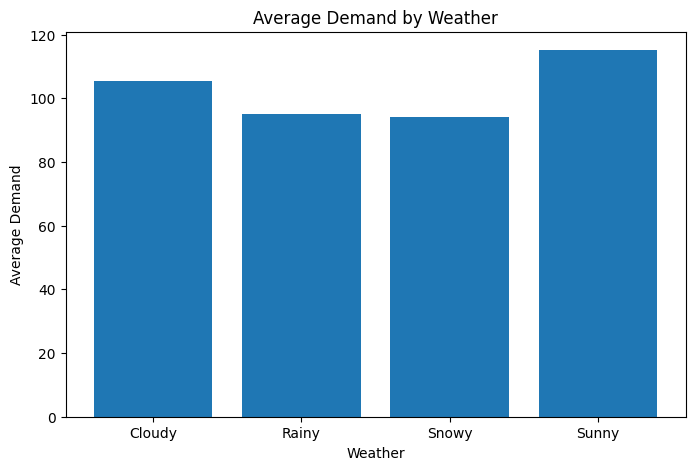

In [379]:
weather = df.groupby("Weather Condition")["Demand"].mean()

plt.figure(figsize=(8,5))
plt.bar(weather.index, weather.values)
plt.title("Average Demand by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Demand")
plt.show()

In [380]:
# Promotion vs Demand

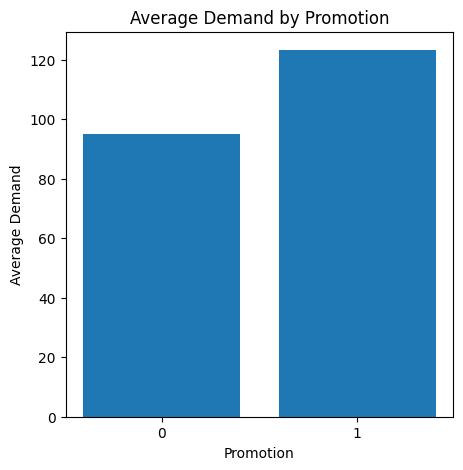

In [381]:
promotion = df.groupby("Promotion")["Demand"].mean()

plt.figure(figsize=(5,5))
plt.bar(promotion.index.astype(str), promotion.values)
plt.title("Average Demand by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Demand")
plt.show()

In [382]:
# Correlation Heatmap

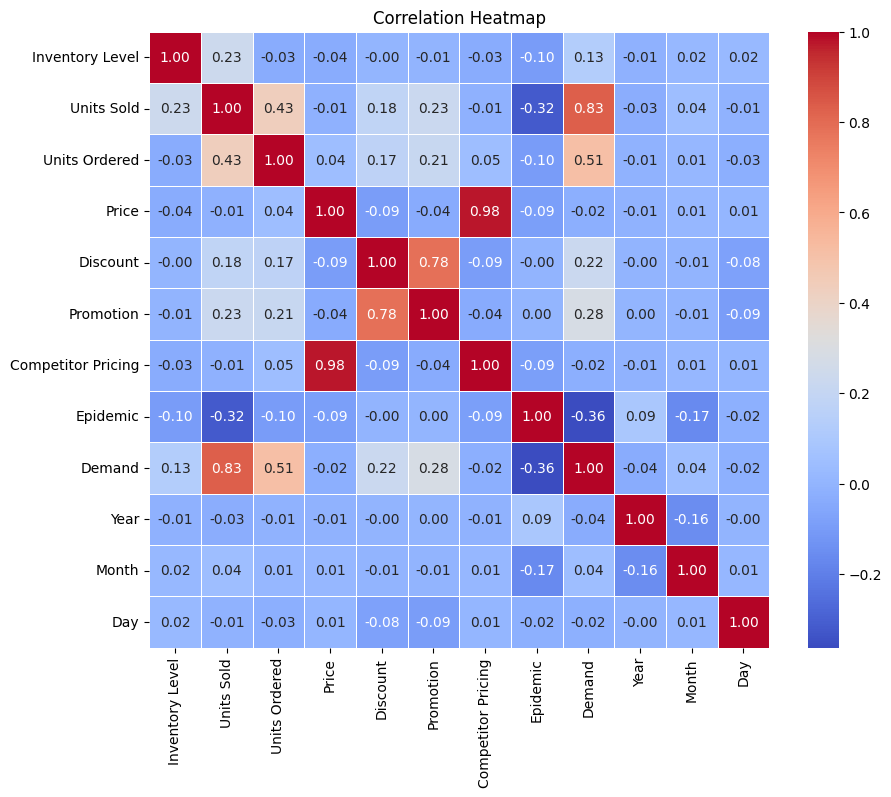

In [383]:

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Correlation Heatmap")
plt.show()

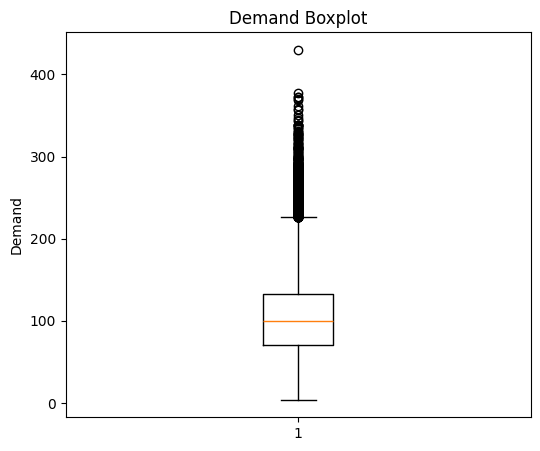

In [384]:
 plt.figure(figsize=(6,5))
plt.boxplot(df["Demand"], vert=True)
plt.title("Demand Boxplot")
plt.ylabel("Demand")
plt.show()

In [385]:
print(df[["Price", "Demand"]].corr())
print(df[["Competitor Pricing", "Demand"]].corr())

           Price    Demand
Price   1.000000 -0.023461
Demand -0.023461  1.000000
                    Competitor Pricing    Demand
Competitor Pricing            1.000000 -0.023036
Demand                       -0.023036  1.000000


In [386]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

In [387]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Seasonality,Epidemic,Demand,Year,Month,Day,DayOfWeek,WeekOfYear,Quarter,IsWeekend
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,Winter,0,115,2022,1,1,5,52,1,1
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,Winter,0,229,2022,1,1,5,52,1,1
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,Winter,0,157,2022,1,1,5,52,1,1
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,Winter,0,52,2022,1,1,5,52,1,1
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,Winter,0,59,2022,1,1,5,52,1,1


In [388]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

In [389]:
# now we have to remove those feature that can cause data leakage

In [390]:
df.drop(
    [
        "Units Sold",
        "Units Ordered",
        "Competitor Pricing"
    ],
    axis=1,
    inplace=True
)

In [391]:
# now we have to seprate the X and y

In [392]:
X = df.drop("Demand", axis=1)

y = df["Demand"]

In [393]:
X.select_dtypes(include="object").columns

Index(['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition',
       'Seasonality'],
      dtype='object')

In [394]:
X = pd.get_dummies(
    X,
    columns=[
        "Store ID",
        "Product ID",
        "Category",
        "Region",
        "Weather Condition",
        "Seasonality"
    ],
    drop_first=True
)

In [409]:
X.head()

,Date,Inventory Level,Price,Discount,Promotion,Epidemic,Year,Month,Day,DayOfWeek,...,Category_Toys,Region_North,Region_South,Region_West,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,2022-01-01,195,72.72,5,0,0,2022,1,1,5,...,False,True,False,False,False,True,False,False,False,True
1,2022-01-01,117,80.16,15,1,0,2022,1,1,5,...,False,True,False,False,False,True,False,False,False,True
2,2022-01-01,247,62.94,10,1,0,2022,1,1,5,...,False,True,False,False,False,True,False,False,False,True
3,2022-01-01,139,87.63,10,0,0,2022,1,1,5,...,False,True,False,False,False,True,False,False,False,True
4,2022-01-01,152,54.41,0,0,0,2022,1,1,5,...,False,True,False,False,False,True,False,False,False,True


In [410]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     76000 non-null  datetime64[ns]
 1   Inventory Level          76000 non-null  int64         
 2   Price                    76000 non-null  float64       
 3   Discount                 76000 non-null  int64         
 4   Promotion                76000 non-null  int64         
 5   Epidemic                 76000 non-null  int64         
 6   Year                     76000 non-null  int32         
 7   Month                    76000 non-null  int32         
 8   Day                      76000 non-null  int32         
 9   DayOfWeek                76000 non-null  int32         
 10  WeekOfYear               76000 non-null  int64         
 11  Quarter                  76000 non-null  int32         
 12  IsWeekend                76000 n

In [397]:
X.isnull().sum()

,0
Date,0
Inventory Level,0
Price,0
Discount,0
Promotion,0
Epidemic,0
Year,0
Month,0
Day,0
DayOfWeek,0


In [411]:
date_col = X["Date"]

bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

X["Date"] = date_col

In [408]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     76000 non-null  datetime64[ns]
 1   Inventory Level          76000 non-null  int64         
 2   Price                    76000 non-null  float64       
 3   Discount                 76000 non-null  int64         
 4   Promotion                76000 non-null  int64         
 5   Epidemic                 76000 non-null  int64         
 6   Year                     76000 non-null  int32         
 7   Month                    76000 non-null  int32         
 8   Day                      76000 non-null  int32         
 9   DayOfWeek                76000 non-null  int32         
 10  WeekOfYear               76000 non-null  int64         
 11  Quarter                  76000 non-null  int32         
 12  IsWeekend                76000 n

In [398]:
# now we will train our data to 80% and test on 20%

In [414]:
X_train = X_train.drop("Date", axis=1)
X_test = X_test.drop("Date", axis=1)

In [401]:
# Linear Regression Model


In [419]:

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [421]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

In [422]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [423]:
y_pred = lr.predict(X_test)

In [424]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 25.724165027096728
MSE : 1098.4128687708946
RMSE: 33.142312363063844
R² Score: 0.4348630296280728


In [425]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
60800,123,99.813539
60801,184,150.925745
60802,114,131.135655
60803,96,110.094256
60804,42,119.617794
60805,102,123.466670
60806,88,107.807370
60807,92,76.925491
60808,179,139.901393
60809,105,97.624030


In [427]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)



DecisionTreeRegressor(random_state=42)

In [428]:
y_pred = dt.predict(X_test)

In [429]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 15.471710526315789
MSE : 524.9893421052632
RMSE: 22.912645899268448
R² Score: 0.7298912870468172


In [433]:
# RandomForest Regressor

In [430]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [431]:
y_pred = rf.predict(X_test)

In [432]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 12.07717302631579
MSE : 295.2813799276316
RMSE: 17.18375337135725
R² Score: 0.848076775860908


In [ ]:
# XGBoost Regressior

In [434]:
xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [435]:
y_pred = xgb.predict(X_test)

In [436]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 12.444889068603516
MSE : 290.4065246582031
RMSE: 17.041318160817347
R² Score: 0.8505849242210388


In [437]:
# KNN

In [438]:
knn = KNeighborsRegressor()

knn.fit(X_train, y_train)

KNeighborsRegressor()

In [439]:
y_pred = knn.predict(X_test)

In [440]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 36.85243421052632
MSE : 2165.5071131578948
RMSE: 46.53500954290108
R² Score: -0.11416040729596633


In [441]:
# SVR

In [442]:
svr = SVR()

svr.fit(X_train, y_train)

SVR()

In [443]:
y_pred = svr.predict(X_test)

In [444]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 34.7782385585893
MSE : 1929.611036540455
RMSE: 43.927338145401606
R² Score: 0.007208886393554659


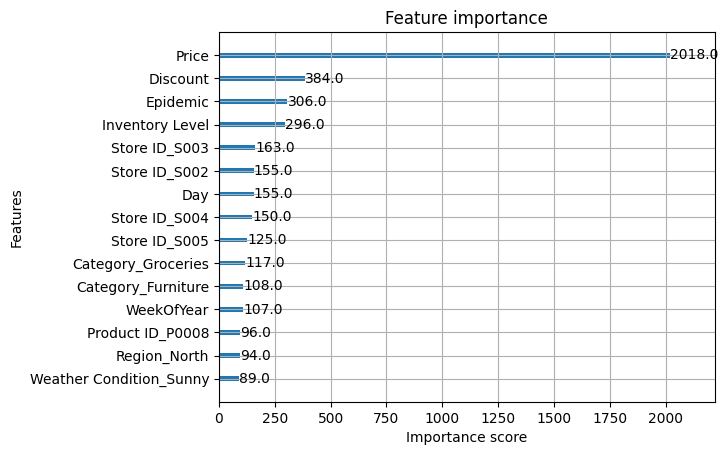

In [446]:
from xgboost import plot_importance

plot_importance(xgb, max_num_features=15)

plt.show()

In [447]:
# now we will do HyperParameter Tunning on XGBoost so maybe the R2 increase or we can decrese the overfitting in our model

In [448]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=20,
    scoring="r2",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

In [450]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)

In [451]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 9.401187896728516
MSE : 155.78965759277344
RMSE: 12.481572721126671
R² Score: 0.919845700263977


In [452]:
# Now compare the traning and testing score to see if it is overfiting ?? or not .

In [453]:
print("Train R²:", best_xgb.score(X_train, y_train))
print("Test R² :", best_xgb.score(X_test, y_test))

Train R²: 0.9586273431777954
Test R² : 0.919845700263977


In [454]:
# this score is good now we can save the model file and we are done here :)

In [455]:
import joblib

joblib.dump(best_xgb, "xgboost_demand_forecasting.pkl")

['xgboost_demand_forecasting.pkl']

In [456]:
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [457]:
df.to_csv("cleaned_demand_forecasting_data.csv", index=False)